In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy import stats
import warnings
from sklearn.model_selection import KFold
from scipy import stats

import utils.model_fitting as fit
from utils.stats_perform import *
from utils.plots import *
from utils.data import *
from utils.path import PathConfig, FigureWithData
from utils.drl import *
from rl.agent import RWLearning
import rl.plots as rlplt

import random

# Set random seed
seed_value = 1234  # Or any integer you like
np.random.seed(seed_value)
random.seed(seed_value)
warnings.filterwarnings("ignore")

fig_dir = os.path.join('figures', 'figure_1')
data_fig_dir = os.path.join('data', 'source_data', 'figure_1')
os.makedirs(fig_dir, exist_ok=True)
os.makedirs(data_fig_dir, exist_ok=True)

    

Saved figure to figures/figure_1/figure_1a.pdf
Saved data and stats to data/figure_data/figure_1/figure_1a.txt


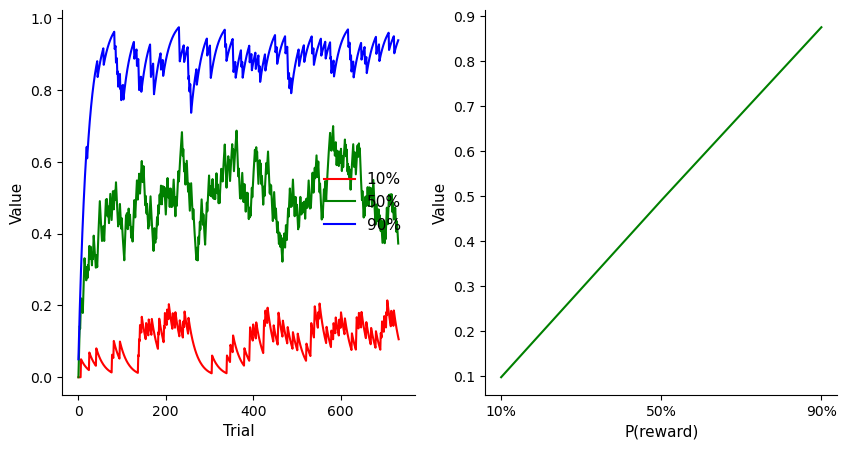

In [5]:
# Traditional distributional RL
color_cs = ['red','green','blue','purple']
taus_rw = np.array([.5])
color_cs = ['red','green','blue','purple']
taus_agents= np.linspace(0.1,.9,5)
probs_cs = np.array([.1, .5, .9])
probs_list = [[iprob,1-iprob] for iprob in probs_cs]
cs_id_list = [[ii,ii] for ii in range(len(probs_cs))]
mags_list = [[1,0] for _ in range(len(probs_cs))]
str_cs_list = ['%.0f%%' % (iprob*100) for iprob in probs_cs]
ntr_convergence=100

ie = 0

s = {}
s['task'] = {}
s['agent'] = {}
s['task']['prob'] = probs_list
s['task']['mags'] = mags_list
s['task']['percent_per_cs'] = 1/len(s['task']['mags'])*np.ones((len(s['task']['mags']),1))
s['task']['cs_id'] = cs_id_list
s['task']['str_cs'] = str_cs_list
s['task']['n_trials'] = 2200
s['task']['cue_onset'] = 1
s['task']['cue_dur'] = 1
s['task']['rew_onset'] = 3
s['task']['iti_dur'] = 1
s['task']['n_iterations'] = 1
s['task']['type'] = 'cue_reward'
s['task']['str_task'] = 'TianUchida'
s['task']['seed'] = seed_value

s['agent']['taus'] =    np.array([taus_rw[ie]])
s['agent']['do_sampling'] = False
s['agent']['str_agent'] = ['Tau_' + str(taus_rw[ie])]#,'neutral','optimistic']
s['agent']['base_alpha'] = .1


agent = RWLearning(s)
agent.run_task()
results = agent.reformat_results()
value_predictions = results['distribution']
deltas_trials = results['deltas_trials']
value_prediction_trials = results['distribution_trials']
n_trials_per_type = results['n_trials_per_type']
mean_converg_vi =np.array([np.mean(value_prediction_trials[ii,:,:int(n_trials_per_type[ii])][-ntr_convergence:])  for ii in range(value_prediction_trials.shape[0])])



fig, ax = plt.subplots(1, 2, figsize=(10, 5))
[ax[0].plot(value_prediction_trials[ii,0,:], color=color_cs[ii],label=s['task']['str_cs'][ii]) for ii in range(3)]
plot_config(ax[0], 'Trial', 'Value', 11,True)
ax[1].plot(mean_converg_vi, color='green')
plot_config(ax[1], 'P(reward)', 'Value', 11,False)
ax[1].set_xticks(np.arange(3))
ax[1].set_xticklabels(s['task']['str_cs'])

# 1. Create the wrapper
fig_data_1a = FigureWithData(fig)

# 2. Panel 0: trial-by-trial value predictions
panel0_data = np.column_stack([value_prediction_trials[ii, 0, :] for ii in range(3)])  # 3 cues
panel0_headers = [f'Cue_{s["task"]["str_cs"][ii]}' for ii in range(3)]
fig_data_1a.add_data(
    "Value prediction per cue (trial-by-trial)",
    panel0_data,
    panel0_headers
)

# 3. Panel 1: mean convergence per cue
panel1_data = np.array(mean_converg_vi)[..., np.newaxis]  # (n_cues, 1)
panel1_headers = ['Mean_value_convergence']
fig_data_1a.add_data(
    "Mean value convergence per cue",
    panel1_data,
    panel1_headers
)

# 4. Save everything
fig_data_1a.save(
    base_filename='figure_1a',
    folder_data= data_fig_dir,
    folder_figures= fig_dir
)






Saved figure to figures/figure_1/figure_1b.pdf
Saved data and stats to data/figure_data/figure_1/figure_1b.txt


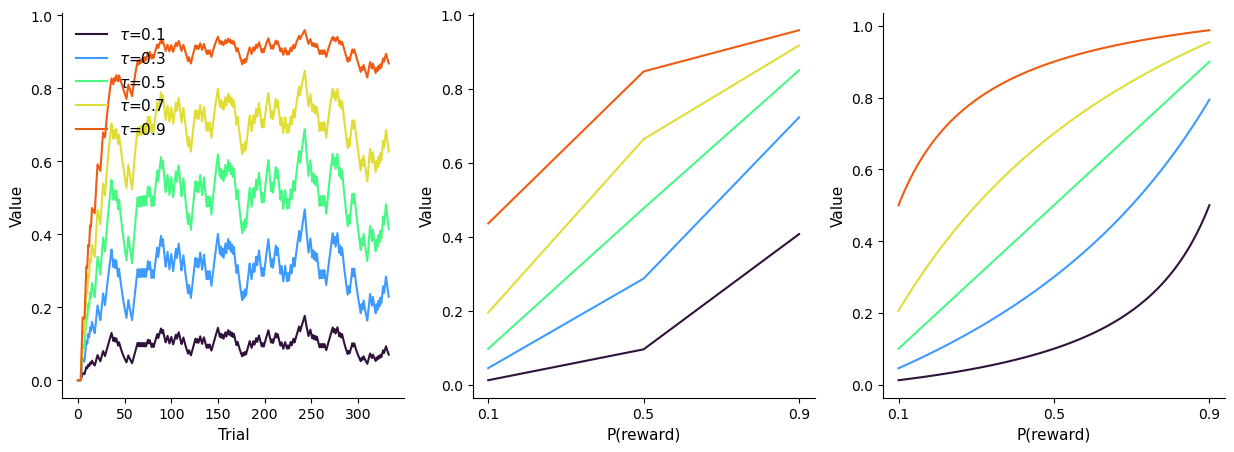

In [7]:
# Risk sensitive  RL
color_cs = ['red','green','blue','purple']
taus_agents= np.linspace(0.1,.9,5)
probs_cs = np.array([.1, .5, .9])
probs_list = [[iprob,1-iprob] for iprob in probs_cs]
cs_id_list = [[ii,ii] for ii in range(len(probs_cs))]
mags_list = [[1,0] for _ in range(len(probs_cs))]
str_cs_list = ['%.0f%%' % (iprob*100) for iprob in probs_cs]

ntr_convergence=100
p_reward_theoretical = np.linspace(.1,.9,100)

value_agents = []
value_agents_iterations = []
value_agents_closed_form = []
for iagent in range(len(taus_agents)):
    s = {}
    s['task'] = {}
    s['agent'] = {}
    s['task']['prob'] = probs_list
    s['task']['mags'] = mags_list
    s['task']['percent_per_cs'] = 1/len(s['task']['mags'])*np.ones((len(s['task']['mags']),1))
    s['task']['cs_id'] = cs_id_list
    s['task']['str_cs'] = str_cs_list
    s['task']['n_trials'] = 1000
    s['task']['cue_onset'] = 1
    s['task']['cue_dur'] = 1
    s['task']['rew_onset'] = 3
    s['task']['iti_dur'] = 1
    s['task']['n_iterations'] = 1
    s['task']['type'] = 'cue_reward'
    s['task']['str_task'] = 'TianUchida'
    s['task']['seed'] = seed_value

    s['agent']['taus'] =    np.array([taus_agents[iagent]])
    s['agent']['do_sampling'] = False
    s['agent']['str_agent'] = ['Tau_' + str(taus_agents[iagent])]#,'neutral','optimistic']
    s['agent']['base_alpha'] = .1


    agent = RWLearning(s)
    agent.run_task()
    results = agent.reformat_results()
    value_predictions = results['distribution']
    deltas_trials = results['deltas_trials']
    value_prediction_trials = results['distribution_trials']
    n_trials_per_type = results['n_trials_per_type']

    mean_converg_vi =[np.mean(value_prediction_trials[ii,:,:int(n_trials_per_type[ii])][-ntr_convergence:])  for ii in range(value_prediction_trials.shape[0])]
    value_closed_form  =np.array([ compute_vi_closed_form(taus_agents[iagent],p,1,0) for p in p_reward_theoretical])
    value_agents.append(mean_converg_vi)
    value_agents_closed_form.append(value_closed_form)
    value_agents_iterations.append(value_prediction_trials)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
_=[ax[0].plot(vi[1,0,:], color=cm.turbo(ii/len(value_agents_iterations)),label=r'$\tau$='+str(np.round(taus_agents[ii],2))) for (ii,vi) in enumerate(value_agents_iterations)]
plot_config(ax[0], 'Trial', 'Value', 11,True)
_=[ax[1].plot(probs_cs,vi, color=cm.turbo(ii/len(value_agents))) for (ii,vi) in enumerate(value_agents)]
plot_config(ax[1], 'P(reward)', 'Value', 11,False)
ax[1].set_xticks(probs_cs)
_=[ax[2].plot(p_reward_theoretical,vi,color=cm.turbo(ii/len(value_agents))) for (ii,vi) in enumerate(value_agents_closed_form)]
plot_config(ax[2], 'P(reward)', 'Value', 11,False)
ax[2].set_xticks(probs_cs)


# 1. Create the wrapper
fig_data_1b = FigureWithData(fig)

# 2. Panel 0: Trial-by-trial value predictions for each agent
panel0_data = np.stack([vi[1, 0, :] for vi in value_agents_iterations], axis=1)  # [trials, agents]
panel0_headers = [f'Tau_{np.round(tau, 2)}' for tau in taus_agents]
fig_data_1b.add_data(
    "Value predictions per agent (trial-by-trial)",
    panel0_data,
    panel0_headers
)

# 3. Panel 1: Mean convergence values
panel1_data = np.stack(value_agents, axis=1)  # [n_probs, agents]
panel1_headers = [f'Tau_{np.round(tau, 2)}' for tau in taus_agents]
fig_data_1b.add_data(
    "Mean convergence value per agent",
    panel1_data,
    panel1_headers
)

# 4. Panel 2: Closed-form predicted value functions
panel2_data = np.stack(value_agents_closed_form, axis=1)  # [n_points, agents]
panel2_headers = [f'Tau_{np.round(tau, 2)}' for tau in taus_agents]
fig_data_1b.add_data(
    "Closed-form value predictions",
    panel2_data,
    panel2_headers
)

# 5. Save everything
fig_data_1b.save(
    base_filename='figure_1b',
    folder_data=data_fig_dir,
    folder_figures=fig_dir
)

Saved figure to figures/figure_1/figure_1c.pdf
Saved data and stats to data/figure_data/figure_1/figure_1c.txt


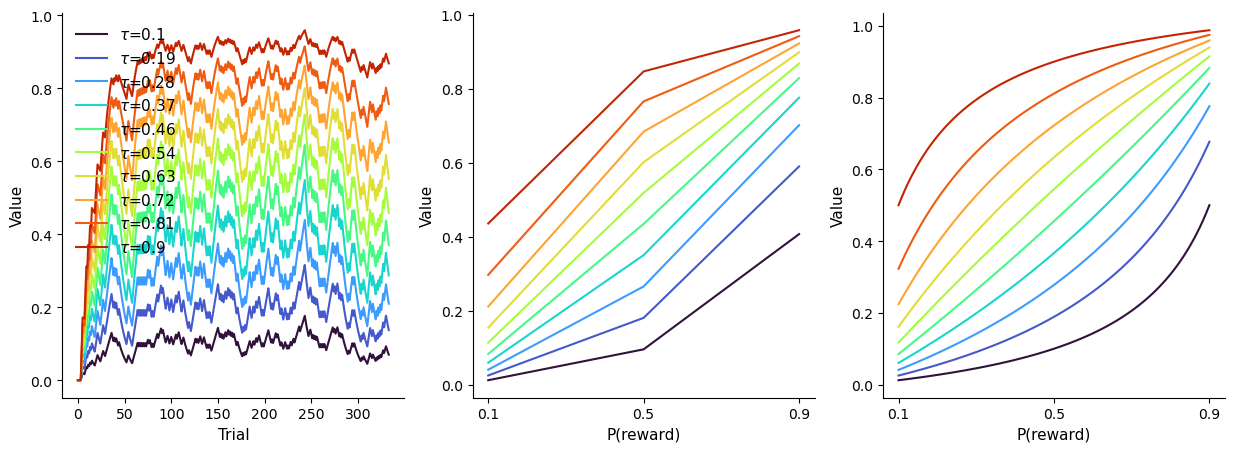

In [8]:
# Distributional RL
color_cs = ['red','green','blue','purple']
taus_agents= np.linspace(0.1,.9,10)
probs_cs = np.array([.1, .5, .9])
probs_list = [[iprob,1-iprob] for iprob in probs_cs]
cs_id_list = [[ii,ii] for ii in range(len(probs_cs))]
mags_list = [[1,0] for _ in range(len(probs_cs))]
str_cs_list = ['%.0f%%' % (iprob*100) for iprob in probs_cs]

ntr_convergence=100
p_reward_theoretical = np.linspace(.1,.9,100)
n_expectiles = len(taus_agents)
value_agents = []
value_agents_iterations = []
value_agents_closed_form = []
s = {}
s['task'] = {}
s['agent'] = {}
s['task']['prob'] = probs_list
s['task']['mags'] = mags_list
s['task']['percent_per_cs'] = 1/len(s['task']['mags'])*np.ones((len(s['task']['mags']),1))
s['task']['cs_id'] = cs_id_list
s['task']['str_cs'] = str_cs_list
s['task']['n_trials'] = 1000
s['task']['cue_onset'] = 1
s['task']['cue_dur'] = 1
s['task']['rew_onset'] = 3
s['task']['iti_dur'] = 1
s['task']['n_iterations'] = 1
s['task']['type'] = 'cue_reward'
s['task']['str_task'] = 'TianUchida'
s['task']['seed'] = seed_value
s['agent']['taus'] =    taus_agents
s['agent']['do_sampling'] = False
s['agent']['str_agent'] = ['Tau_' + str(taus_agents[iagent])]#,'neutral','optimistic']
s['agent']['base_alpha'] = .1


agent = RWLearning(s)
agent.run_task()
results = agent.reformat_results()
value_predictions = results['distribution']
deltas_trials = results['deltas_trials']
value_prediction_trials = results['distribution_trials']
n_trials_per_type = results['n_trials_per_type']

mean_converg_vi =np.array([np.mean(value_prediction_trials[ii,:,:int(n_trials_per_type[ii])][-ntr_convergence:],axis=1)  for ii in range(value_prediction_trials.shape[0])])
value_closed_form  =np.array([[ compute_vi_closed_form(taus_agents[iagent],p,1,0) for p in p_reward_theoretical] for iagent in range(len(taus_agents))])
value_prediction_trials.shape

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
_=[ax[0].plot(value_prediction_trials[1,ii,:], color=cm.turbo(ii/n_expectiles),label=r'$\tau$='+str(np.round(taus_agents[ii],2))) for ii in range(n_expectiles)]
plot_config(ax[0], 'Trial', 'Value', 11,True)
_=[ax[1].plot(probs_cs,mean_converg_vi[:,ii], color=cm.turbo(ii/n_expectiles)) for ii in range(n_expectiles)]
plot_config(ax[1], 'P(reward)', 'Value', 11,False)
ax[1].set_xticks(probs_cs)
_=[ax[2].plot(p_reward_theoretical,value_closed_form[ii,:],color=cm.turbo(ii/n_expectiles)) for ii in range(n_expectiles)]
plot_config(ax[2], 'P(reward)', 'Value', 11,False)
ax[2].set_xticks(probs_cs)


# --- Prepare data to save ---
# 1. Create the wrapper
fig_data_1c = FigureWithData(fig)

# 2. Panel 0: Trial-by-trial value predictions per expectile
panel0_data = np.stack([value_prediction_trials[1, ii, :] for ii in range(n_expectiles)], axis=1)
panel0_headers = [f'Tau_{np.round(taus_agents[ii], 2)}' for ii in range(n_expectiles)]
fig_data_1c.add_data(
    "Value predictions per expectile (trial-by-trial)",
    panel0_data,
    panel0_headers
)

# 3. Panel 1: Mean convergence per expectile
panel1_data = np.stack([mean_converg_vi[:, ii] for ii in range(n_expectiles)], axis=1)
panel1_headers = [f'Tau_{np.round(taus_agents[ii], 2)}' for ii in range(n_expectiles)]
fig_data_1c.add_data(
    "Mean convergence value per expectile",
    panel1_data,
    panel1_headers
)

# 4. Panel 2: Closed-form predictions per expectile
panel2_data = np.stack([value_closed_form[ii, :] for ii in range(n_expectiles)], axis=1)
panel2_headers = [f'Tau_{np.round(taus_agents[ii], 2)}' for ii in range(n_expectiles)]
fig_data_1c.add_data(
    "Closed-form value predictions per expectile",
    panel2_data,
    panel2_headers
)

# 5. Save everything
fig_data_1c.save(
    base_filename='figure_1c',
    folder_data= data_fig_dir,
    folder_figures=fig_dir
)
